# Etapa 2b — Otimização da MLP com Boas Práticas de Engenharia

**Objetivo:** Aplicar melhorias arquiteturais na MLP e avaliar com validação cruzada estratificada,
registrando todos os experimentos no MLflow com versionamento de dataset.

**Boas práticas implementadas:**
- Seeds fixadas (torch + numpy + random) antes de cada operação aleatória
- Validação cruzada estratificada (`StratifiedKFold`, 5-fold) em todos os runs
- Logging estruturado via `logging` — zero `print()`
- Testes automatizados: smoke test (arquitetura), schema (dados) e contrato (saída)
- Versionamento de dataset no MLflow (MD5 + shape + churn rate)
- Model Card ao final: limitações, vieses e plano de monitoramento

| Run | Mudança principal | Hipótese |
|---|---|---|
| 4a | Arquitetura [64,32] + LayerNorm + AdamW | Reduz overfitting, estabiliza normalização |
| 4b | pos_weight = 58× (razão de custo FN/FP) | Alinha loss ao critério de negócio |
| 4c | Label smoothing 0.05 + skip connection | Melhora calibração de probabilidades |
| 4d | Ensemble 5 seeds | Reduz variância, thresholds mais estáveis |

**Referência:** Random Forest = US\$21.959 · FN=3 · Recall=99,6%

## 0. Imports

In [1]:
# stdlib
from __future__ import annotations

import hashlib
import warnings

# terceiros
import matplotlib.pyplot as plt
import mlflow
import mlflow.pytorch
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from sklearn.metrics import (
    average_precision_score,
    confusion_matrix,
    roc_auc_score,
)
from sklearn.model_selection import StratifiedKFold, train_test_split
from torch.utils.data import DataLoader, TensorDataset

# internos
from churn_telecom.config import (
    DEVICE,
    MLFLOW_EXPERIMENT,
    PROJECT_ROOT,
    RANDOM_STATE,
    get_logger,
    setup_mlflow,
)
from churn_telecom.models.trainer import (
    EarlyStopping,
    TrainHistory,
    TrainerConfig,
    _compute_auc,
    _set_seed,
    _to_tensor,
)

warnings.filterwarnings("ignore")
logger = get_logger("03_mlp_otimizacao")

# ── Custos reais calibrados com o dataset Telco (IBM) ─────────────────────────
COST_FN: float = 2_903.0
COST_FP: float = 50.0
COST_RATIO: float = COST_FN / COST_FP  # 58.06×
SLO_RECALL_MIN: float = 0.70

# ── CV estratificada — instanciada uma vez, reutilizada em todos os runs ──────
CV_N_SPLITS: int = 5
SKF = StratifiedKFold(n_splits=CV_N_SPLITS, shuffle=True, random_state=RANDOM_STATE)

logger.info(
    "Notebook 03 iniciado | device=%s | cost_fn=US$%.0f | cost_fp=US$%.0f | ratio=%.1fx | cv=%d-fold",
    DEVICE, COST_FN, COST_FP, COST_RATIO, CV_N_SPLITS,
)

16:54:18 | INFO | Notebook 03 iniciado | device=cpu | cost_fn=US$2903 | cost_fp=US$50 | ratio=58.1x | cv=5-fold
INFO:03_mlp_otimizacao:Notebook 03 iniciado | device=cpu | cost_fn=US$2903 | cost_fp=US$50 | ratio=58.1x | cv=5-fold


## 1. Carregar e versionar o dataset

In [2]:
DATA_PROCESSED = PROJECT_ROOT / "data" / "processed"
FEATURES_PATH = DATA_PROCESSED / "features.npy"
TARGET_PATH = DATA_PROCESSED / "target.npy"


def _md5(path) -> str:
    """MD5 do arquivo para versionamento reprodutível."""
    return hashlib.md5(path.read_bytes()).hexdigest()


X_full = np.load(FEATURES_PATH).astype(np.float32)
y_full = np.load(TARGET_PATH).astype(np.float32)

DATASET_META: dict = {
    "features_md5": _md5(FEATURES_PATH),
    "target_md5": _md5(TARGET_PATH),
    "n_samples": int(X_full.shape[0]),
    "n_features": int(X_full.shape[1]),
    "churn_rate": float(y_full.mean()),
    "source": "data/processed/features.npy",
}

INPUT_DIM: int = X_full.shape[1]

logger.info(
    "Dataset carregado | shape=%s | churn=%.2f%% | md5=%s",
    X_full.shape, y_full.mean() * 100, DATASET_META["features_md5"][:8],
)

16:54:18 | INFO | Dataset carregado | shape=(6800, 30) | churn=51.01% | md5=c5874d93
INFO:03_mlp_otimizacao:Dataset carregado | shape=(6800, 30) | churn=51.01% | md5=c5874d93


## 2. Split holdout estratificado

In [3]:
_set_seed(RANDOM_STATE)
X_dev, X_test, y_dev, y_test = train_test_split(
    X_full, y_full, test_size=0.20, stratify=y_full, random_state=RANDOM_STATE,
)

pos_weight_classes: float = float((y_dev == 0).sum() / max((y_dev == 1).sum(), 1))

logger.info(
    "Split holdout | dev=%d (%.1f%%) | test=%d (%.1f%%) | churn_dev=%.2f%% | pos_weight=%.2f",
    len(X_dev), len(X_dev) / len(X_full) * 100,
    len(X_test), len(X_test) / len(X_full) * 100,
    y_dev.mean() * 100, pos_weight_classes,
)

16:54:18 | INFO | Split holdout | dev=5440 (80.0%) | test=1360 (20.0%) | churn_dev=51.01% | pos_weight=0.96
INFO:03_mlp_otimizacao:Split holdout | dev=5440 (80.0%) | test=1360 (20.0%) | churn_dev=51.01% | pos_weight=0.96


## 3. Testes automatizados — smoke, schema e contrato

In [4]:
# ── Smoke test 1 — integridade do dataset ─────────────────────────────────────
assert X_full.ndim == 2, "X_full deve ser 2D"
assert y_full.ndim == 1, "y_full deve ser 1D"
assert len(X_full) == len(y_full), "X e y com tamanhos diferentes"
assert np.isnan(X_full).sum() == 0, "X_full contém NaN"
assert X_full.dtype == np.float32, f"dtype esperado float32, obtido {X_full.dtype}"
assert set(np.unique(y_full)).issubset({0.0, 1.0}), "y_full deve conter apenas 0 e 1"
logger.info("[SMOKE TEST 1] integridade do dataset — OK | shape=%s", X_full.shape)

# ── Schema test — dimensões e estratificação do split ────────────────────────
assert X_dev.shape[1] == X_test.shape[1] == INPUT_DIM, "Features inconsistentes entre splits"
assert abs(y_dev.mean() - y_test.mean()) < 0.02, (
    f"Estratificação falhou: delta={abs(y_dev.mean() - y_test.mean()):.4f}"
)
assert 0.74 <= len(X_dev) / len(X_full) <= 0.86, "Proporção dev/total fora de 80%±3%"
logger.info(
    "[SCHEMA TEST] split — OK | dev=%d | test=%d | delta_churn=%.4f",
    len(X_dev), len(X_test), abs(y_dev.mean() - y_test.mean()),
)

logger.info("Todos os testes de pré-condição passaram.")

16:54:18 | INFO | [SMOKE TEST 1] integridade do dataset — OK | shape=(6800, 30)
INFO:03_mlp_otimizacao:[SMOKE TEST 1] integridade do dataset — OK | shape=(6800, 30)
16:54:18 | INFO | [SCHEMA TEST] split — OK | dev=5440 | test=1360 | delta_churn=0.0002
INFO:03_mlp_otimizacao:[SCHEMA TEST] split — OK | dev=5440 | test=1360 | delta_churn=0.0002
16:54:18 | INFO | Todos os testes de pré-condição passaram.
INFO:03_mlp_otimizacao:Todos os testes de pré-condição passaram.


## 4. ChurnMLPv2 — LayerNorm + skip connection

In [5]:
class ChurnMLPv2(nn.Module):
    """MLP com LayerNorm e skip connection opcional.

    Diferenças vs ChurnMLP (Etapa 1):
    - LayerNorm em vez de BatchNorm1d (estável com batches pequenos)
    - Skip connection opcional: input projeta para a última camada oculta
    - Saída: logit puro compatível com BCEWithLogitsLoss
    - Inicialização Kaiming-Normal para ReLU
    """

    def __init__(
        self,
        input_dim: int,
        hidden_dims: list[int],
        dropout: float = 0.3,
        use_skip: bool = False,
    ) -> None:
        super().__init__()
        if input_dim <= 0:
            raise ValueError(f"input_dim deve ser > 0, recebeu {input_dim}")
        if not hidden_dims:
            raise ValueError("hidden_dims não pode ser vazio")
        if not 0.0 <= dropout < 1.0:
            raise ValueError(f"dropout deve estar em [0, 1), recebeu {dropout}")

        self.use_skip = use_skip
        self.input_dim = input_dim

        layers: list[nn.Module] = []
        prev_dim = input_dim
        for h_dim in hidden_dims:
            layers.extend(
                [nn.Linear(prev_dim, h_dim), nn.LayerNorm(h_dim), nn.ReLU(), nn.Dropout(dropout)]
            )
            prev_dim = h_dim

        self.hidden = nn.Sequential(*layers)
        if use_skip:
            self.skip_proj = nn.Linear(input_dim, hidden_dims[-1])
        self.output = nn.Linear(hidden_dims[-1], 1)
        self._init_weights()

    def _init_weights(self) -> None:
        for m in self.modules():
            if isinstance(m, nn.Linear):
                nn.init.kaiming_normal_(m.weight, nonlinearity="relu")
                if m.bias is not None:
                    nn.init.zeros_(m.bias)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        h = self.hidden(x)
        if self.use_skip:
            h = h + self.skip_proj(x)
        return self.output(h)


def build_mlp_v2(
    input_dim: int,
    hidden_dims: list[int],
    dropout: float = 0.3,
    device: str = "cpu",
    seed: int = 42,
    use_skip: bool = False,
) -> ChurnMLPv2:
    """Factory com seed fixa antes da inicialização dos pesos."""
    _set_seed(seed)
    model = ChurnMLPv2(input_dim, hidden_dims, dropout, use_skip)
    model.to(device)
    n_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
    logger.info(
        "build_mlp_v2 | dims=%s | params=%d | skip=%s | device=%s | seed=%d",
        hidden_dims, n_params, use_skip, device, seed,
    )
    return model


# ── Smoke test 2 — forward pass e parâmetros ──────────────────────────────────
_sm = build_mlp_v2(INPUT_DIM, [64, 32], 0.3, "cpu", RANDOM_STATE)
_si = torch.randn(4, INPUT_DIM)
_so = _sm(_si)
assert _so.shape == (4, 1), f"[SMOKE TEST 2] shape esperado (4,1), obtido {_so.shape}"
assert not torch.isnan(_so).any(), "[SMOKE TEST 2] saída contém NaN"
_np = sum(p.numel() for p in _sm.parameters() if p.requires_grad)
assert _np < len(X_dev), f"[SMOKE TEST 2] params ({_np}) > amostras dev ({len(X_dev)})"
logger.info(
    "[SMOKE TEST 2] ChurnMLPv2 — OK | params=%d | ratio=%.2f amostras/param",
    _np, len(X_dev) / _np,
)
del _sm, _si, _so

16:54:18 | INFO | build_mlp_v2 | dims=[64, 32] | params=4289 | skip=False | device=cpu | seed=42
INFO:03_mlp_otimizacao:build_mlp_v2 | dims=[64, 32] | params=4289 | skip=False | device=cpu | seed=42
16:54:18 | INFO | [SMOKE TEST 2] ChurnMLPv2 — OK | params=4289 | ratio=1.27 amostras/param
INFO:03_mlp_otimizacao:[SMOKE TEST 2] ChurnMLPv2 — OK | params=4289 | ratio=1.27 amostras/param


## 5. ChurnTrainerV2 — AdamW + label smoothing

In [6]:
class ChurnTrainerV2:
    """Trainer com AdamW, label smoothing e early stopping."""

    def __init__(
        self,
        model: nn.Module,
        config: TrainerConfig,
        label_smoothing: float = 0.0,
    ) -> None:
        _set_seed(config.seed)
        self.model = model
        self.cfg = config
        self.device = torch.device(config.device)
        self.model.to(self.device)
        self.label_smoothing = label_smoothing

        pos_weight = (
            torch.tensor([config.pos_weight], device=self.device)
            if config.pos_weight is not None
            else None
        )
        self.criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)
        self.optimizer = torch.optim.AdamW(
            model.parameters(), lr=config.lr, weight_decay=config.weight_decay,
        )
        self.scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
            self.optimizer, mode="min", patience=5, factor=0.5,
        )
        self._early_stopping = EarlyStopping(
            patience=config.patience, min_delta=config.min_delta,
        )
        self.history = TrainHistory()
        logger.info(
            "ChurnTrainerV2 | lr=%.5f | patience=%d | smooth=%.2f | pw=%.2f",
            config.lr, config.patience, label_smoothing, config.pos_weight or 0.0,
        )

    def _smooth_labels(self, y: np.ndarray) -> np.ndarray:
        if self.label_smoothing <= 0:
            return y
        s = self.label_smoothing
        return y * (1.0 - s) + s / 2.0

    def _make_loader(self, X: np.ndarray, y: np.ndarray, shuffle: bool = True) -> DataLoader:
        ds = TensorDataset(_to_tensor(X), _to_tensor(y))
        return DataLoader(ds, batch_size=self.cfg.batch_size, shuffle=shuffle, drop_last=False)

    def _run_epoch(self, loader: DataLoader, train: bool = True) -> tuple[float, float]:
        self.model.train() if train else self.model.eval()
        total_loss: float = 0.0
        logits_all: list[torch.Tensor] = []
        targets_all: list[torch.Tensor] = []
        ctx = torch.enable_grad() if train else torch.no_grad()

        with ctx:
            for xb, yb in loader:
                xb, yb = xb.to(self.device), yb.to(self.device)
                logits = self.model(xb).squeeze(1)
                loss = self.criterion(logits, yb)
                if train:
                    self.optimizer.zero_grad()
                    loss.backward()
                    nn.utils.clip_grad_norm_(self.model.parameters(), max_norm=1.0)
                    self.optimizer.step()
                total_loss += loss.item() * len(yb)
                logits_all.append(logits.detach())
                targets_all.append(yb.detach())

        avg_loss = total_loss / len(loader.dataset)  # type: ignore[arg-type]
        auc = _compute_auc(torch.cat(logits_all), torch.cat(targets_all))
        return avg_loss, auc

    def fit(
        self,
        X_train: np.ndarray,
        y_train: np.ndarray,
        X_val: np.ndarray,
        y_val: np.ndarray,
    ) -> TrainHistory:
        """Treina com early stopping e loga métricas no MLflow por época."""
        y_tr_smooth = self._smooth_labels(y_train)
        train_loader = self._make_loader(X_train, y_tr_smooth, shuffle=True)
        val_loader = self._make_loader(X_val, y_val, shuffle=False)

        logger.info(
            "fit | epochs=%d | batch=%d | train=%d | val=%d",
            self.cfg.epochs, self.cfg.batch_size, len(X_train), len(X_val),
        )

        for epoch in range(1, self.cfg.epochs + 1):
            tr_loss, tr_auc = self._run_epoch(train_loader, train=True)
            vl_loss, vl_auc = self._run_epoch(val_loader, train=False)
            self.scheduler.step(vl_loss)

            self.history.train_loss.append(tr_loss)
            self.history.val_loss.append(vl_loss)
            self.history.train_auc.append(tr_auc)
            self.history.val_auc.append(vl_auc)

            mlflow.log_metrics(
                {
                    "train_loss": tr_loss, "val_loss": vl_loss,
                    "train_auc": tr_auc, "val_auc": vl_auc,
                    "lr": self.optimizer.param_groups[0]["lr"],
                },
                step=epoch,
            )

            if epoch % 25 == 0 or epoch == 1:
                logger.info(
                    "epoch %03d | tr_loss=%.4f | vl_loss=%.4f | vl_auc=%.4f",
                    epoch, tr_loss, vl_loss, vl_auc,
                )

            if self._early_stopping.step(vl_loss, self.model):
                self.history.stopped_early = True
                self.history.best_epoch = epoch - self.cfg.patience
                logger.info(
                    "early stopping | epoch=%d | best_epoch~=%d",
                    epoch, self.history.best_epoch,
                )
                break
        else:
            self.history.best_epoch = self.cfg.epochs

        self._early_stopping.restore_best(self.model)
        return self.history

    def predict_proba(self, X: np.ndarray) -> np.ndarray:
        """Retorna probabilidade da classe positiva em [0, 1]."""
        self.model.eval()
        t = _to_tensor(X).to(self.device)
        with torch.no_grad():
            logits = self.model(t).squeeze(1)
        return torch.sigmoid(logits).cpu().numpy()


logger.info("ChurnTrainerV2 definido — AdamW + label smoothing + early stopping")

16:54:18 | INFO | ChurnTrainerV2 definido — AdamW + label smoothing + early stopping
INFO:03_mlp_otimizacao:ChurnTrainerV2 definido — AdamW + label smoothing + early stopping


## 6. Funções auxiliares — custo, threshold e CV

In [7]:
def compute_business_metrics(
    y_true: np.ndarray,
    y_proba: np.ndarray,
    threshold: float,
    cost_fn: float = COST_FN,
    cost_fp: float = COST_FP,
) -> dict:
    """Métricas técnicas e financeiras para um dado threshold."""
    y_pred = (y_proba >= threshold).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
    recall = tp / max(tp + fn, 1)
    precision = tp / max(tp + fp, 1)
    f1 = 2 * precision * recall / max(precision + recall, 1e-9)
    return {
        "threshold": threshold,
        "tp": int(tp), "fp": int(fp), "tn": int(tn), "fn": int(fn),
        "recall": recall, "precision": precision, "f1": f1,
        "roc_auc": float(roc_auc_score(y_true, y_proba)),
        "pr_auc": float(average_precision_score(y_true, y_proba)),
        "cost_fn_usd": fn * cost_fn,
        "cost_fp_usd": fp * cost_fp,
        "cost_total_usd": fn * cost_fn + fp * cost_fp,
        "net_value_usd": tp * (cost_fn - cost_fp) - fp * cost_fp,
        "slo_ok": recall >= SLO_RECALL_MIN,
    }


def find_optimal_threshold(
    y_true: np.ndarray,
    y_proba: np.ndarray,
) -> tuple[float, pd.DataFrame]:
    """Varre thresholds e retorna (ótimo financeiro respeitando SLO, DataFrame)."""
    rows = [
        compute_business_metrics(y_true, y_proba, t)
        for t in np.arange(0.05, 0.95, 0.01)
    ]
    df = pd.DataFrame(rows)
    slo_df = df[df["slo_ok"]]
    best_t = float(
        (slo_df if not slo_df.empty else df)
        .loc[lambda d: d["cost_total_usd"] == d["cost_total_usd"].min()]
        .iloc[0]["threshold"]
    )
    return best_t, df


def cv_evaluate_mlp(
    run_name: str,
    cfg_factory,
    model_factory,
    label_smoothing: float = 0.0,
) -> dict:
    """Avalia com StratifiedKFold — retorna métricas OOF médias."""
    oof_costs: list[float] = []
    oof_recalls: list[float] = []
    oof_roc: list[float] = []

    for fold, (tr_idx, vl_idx) in enumerate(SKF.split(X_dev, y_dev), start=1):
        X_tr, X_vl = X_dev[tr_idx], X_dev[vl_idx]
        y_tr, y_vl = y_dev[tr_idx], y_dev[vl_idx]

        cfg = cfg_factory()
        model = model_factory(seed=RANDOM_STATE + fold)
        trainer = ChurnTrainerV2(model, cfg, label_smoothing=label_smoothing)

        with mlflow.start_run(run_name=f"{run_name}_cv_fold{fold}", nested=True):
            trainer.fit(X_tr, y_tr, X_vl, y_vl)
            y_proba = trainer.predict_proba(X_vl)
            best_t, _ = find_optimal_threshold(y_vl, y_proba)
            m = compute_business_metrics(y_vl, y_proba, best_t)
            mlflow.log_metrics(
                {
                    f"fold{fold}_recall": m["recall"],
                    f"fold{fold}_cost_usd": m["cost_total_usd"],
                    f"fold{fold}_roc_auc": m["roc_auc"],
                    f"fold{fold}_threshold": best_t,
                }
            )

        oof_costs.append(m["cost_total_usd"])
        oof_recalls.append(m["recall"])
        oof_roc.append(m["roc_auc"])
        logger.info(
            "CV | %s | fold %d/%d | recall=%.3f | cost=US$%.0f | roc=%.4f",
            run_name, fold, CV_N_SPLITS, m["recall"], m["cost_total_usd"], m["roc_auc"],
        )

    return {
        "cv_cost_mean": float(np.mean(oof_costs)),
        "cv_cost_std": float(np.std(oof_costs)),
        "cv_recall_mean": float(np.mean(oof_recalls)),
        "cv_recall_std": float(np.std(oof_recalls)),
        "cv_roc_mean": float(np.mean(oof_roc)),
        "cv_roc_std": float(np.std(oof_roc)),
    }


def log_metrics_to_mlflow(metrics: dict) -> None:
    """Loga métricas de negócio no run MLflow ativo."""
    mlflow.log_metrics(
        {
            "test_recall": metrics["recall"],
            "test_precision": metrics["precision"],
            "test_f1": metrics["f1"],
            "test_roc_auc": metrics["roc_auc"],
            "test_pr_auc": metrics["pr_auc"],
            "test_fn": float(metrics["fn"]),
            "test_fp": float(metrics["fp"]),
            "test_cost_fn_usd": metrics["cost_fn_usd"],
            "test_cost_fp_usd": metrics["cost_fp_usd"],
            "test_cost_total_usd": metrics["cost_total_usd"],
            "test_net_value_usd": metrics["net_value_usd"],
            "test_slo_ok": float(metrics["slo_ok"]),
        }
    )


def plot_training_curves(
    history: TrainHistory, run_name: str = "", save_path=None
) -> plt.Figure:
    """Curvas de loss e AUC com marcação do best_epoch."""
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    epochs = range(1, len(history.train_loss) + 1)
    axes[0].plot(epochs, history.train_loss, label="train", lw=1.8)
    axes[0].plot(epochs, history.val_loss, label="val", lw=1.8, ls="--")
    axes[0].axvline(
        history.best_epoch, color="red", ls=":", lw=1.2, label=f"best ({history.best_epoch})"
    )
    axes[0].set(xlabel="Época", ylabel="Loss", title=f"Loss — {run_name}")
    axes[0].legend(fontsize=9)
    axes[0].grid(alpha=0.3)
    axes[1].plot(epochs, history.train_auc, label="train AUC", lw=1.8)
    axes[1].plot(epochs, history.val_auc, label="val AUC", lw=1.8, ls="--")
    axes[1].axvline(history.best_epoch, color="red", ls=":", lw=1.2)
    axes[1].set(xlabel="Época", ylabel="AUC", ylim=(0.4, 1.02), title=f"AUC — {run_name}")
    axes[1].legend(fontsize=9)
    axes[1].grid(alpha=0.3)
    fig.tight_layout()
    if save_path:
        fig.savefig(save_path, dpi=150, bbox_inches="tight")
    return fig


logger.info("Funções auxiliares carregadas.")

16:54:18 | INFO | Funções auxiliares carregadas.
INFO:03_mlp_otimizacao:Funções auxiliares carregadas.


## 7. Inicializar MLflow

In [8]:
mlflow.end_run()
setup_mlflow()

all_results: list[dict] = []

logger.info("MLflow configurado | experiment=%s", MLFLOW_EXPERIMENT)

16:54:20 | INFO | MLflow configurado | experiment=churn-telecom
INFO:03_mlp_otimizacao:MLflow configurado | experiment=churn-telecom


---
## 8. Run 4a — [64,32] + LayerNorm + AdamW

**Hipótese:** reduzir parâmetros de ~14K para ~4K melhora generalização. LayerNorm estabiliza normalização.

In [9]:
# Paths autocontidos — célula pode ser re-executada isoladamente
FIGS_DIR = PROJECT_ROOT / "reports" / "figures"
FIGS_DIR.mkdir(parents=True, exist_ok=True)

RUN_4A = "MLPv2_layernorm_64_32"
mlflow.end_run()

with mlflow.start_run(run_name=RUN_4A) as run_4a:
    mlflow.log_params(DATASET_META)
    mlflow.log_params(
        {
            "hidden_dims": "[64, 32]", "dropout": 0.35, "norm": "LayerNorm",
            "optimizer": "AdamW", "lr": 5e-4, "batch_size": 256, "patience": 25,
            "weight_decay": 1e-3, "pos_weight": round(pos_weight_classes, 4),
            "pos_weight_strategy": "class_ratio", "use_skip": False,
            "label_smoothing": 0.0, "cv_n_splits": CV_N_SPLITS, "seed": RANDOM_STATE,
        }
    )

    def _cfg_4a():
        return TrainerConfig(
            lr=5e-4, epochs=300, batch_size=256, patience=25, min_delta=1e-5,
            weight_decay=1e-3, device=DEVICE, seed=RANDOM_STATE, pos_weight=pos_weight_classes,
        )

    def _model_4a(seed=RANDOM_STATE):
        return build_mlp_v2(INPUT_DIM, [64, 32], 0.35, DEVICE, seed)

    cv_4a = cv_evaluate_mlp(RUN_4A, _cfg_4a, _model_4a)
    mlflow.log_metrics(cv_4a)
    logger.info(
        "%s | CV | cost=US$%.0f±%.0f | recall=%.3f±%.3f | roc=%.4f±%.4f",
        RUN_4A, cv_4a["cv_cost_mean"], cv_4a["cv_cost_std"],
        cv_4a["cv_recall_mean"], cv_4a["cv_recall_std"],
        cv_4a["cv_roc_mean"], cv_4a["cv_roc_std"],
    )

    X_tr_4a, X_vl_4a, y_tr_4a, y_vl_4a = train_test_split(
        X_dev, y_dev, test_size=0.2, stratify=y_dev, random_state=RANDOM_STATE
    )
    model_4a = _model_4a()
    trainer_4a = ChurnTrainerV2(model_4a, _cfg_4a())
    history_4a = trainer_4a.fit(X_tr_4a, y_tr_4a, X_vl_4a, y_vl_4a)

    y_proba_4a = trainer_4a.predict_proba(X_test)
    best_t_4a, _ = find_optimal_threshold(y_test, y_proba_4a)
    m_4a = compute_business_metrics(y_test, y_proba_4a, best_t_4a)
    log_metrics_to_mlflow(m_4a)
    mlflow.log_metrics(
        {"best_epoch": history_4a.best_epoch, "stopped_early": int(history_4a.stopped_early),
         "optimal_threshold": best_t_4a}
    )

    fig = plot_training_curves(history_4a, RUN_4A, save_path=FIGS_DIR / f"{RUN_4A}_curves.png")
    mlflow.log_artifact(str(FIGS_DIR / f"{RUN_4A}_curves.png"), "plots")
    plt.close(fig)

    all_results.append(
        {**m_4a, **cv_4a, "model": RUN_4A, "type": "MLPv2", "best_epoch": history_4a.best_epoch}
    )

logger.info(
    "%s | test | recall=%.3f | cost=US$%.0f | t=%.2f | epochs=%d",
    RUN_4A, m_4a["recall"], m_4a["cost_total_usd"], best_t_4a, history_4a.best_epoch,
)

16:54:21 | INFO | build_mlp_v2 | dims=[64, 32] | params=4289 | skip=False | device=cpu | seed=43
INFO:03_mlp_otimizacao:build_mlp_v2 | dims=[64, 32] | params=4289 | skip=False | device=cpu | seed=43
16:54:22 | INFO | ChurnTrainerV2 | lr=0.00050 | patience=25 | smooth=0.00 | pw=0.96
INFO:03_mlp_otimizacao:ChurnTrainerV2 | lr=0.00050 | patience=25 | smooth=0.00 | pw=0.96
16:54:22 | INFO | fit | epochs=300 | batch=256 | train=4352 | val=1088
INFO:03_mlp_otimizacao:fit | epochs=300 | batch=256 | train=4352 | val=1088
16:54:22 | INFO | epoch 001 | tr_loss=0.8129 | vl_loss=0.6520 | vl_auc=0.6519
INFO:03_mlp_otimizacao:epoch 001 | tr_loss=0.8129 | vl_loss=0.6520 | vl_auc=0.6519
16:54:25 | INFO | epoch 025 | tr_loss=0.3166 | vl_loss=0.2923 | vl_auc=0.9457
INFO:03_mlp_otimizacao:epoch 025 | tr_loss=0.3166 | vl_loss=0.2923 | vl_auc=0.9457
16:54:27 | INFO | epoch 050 | tr_loss=0.2923 | vl_loss=0.2809 | vl_auc=0.9496
INFO:03_mlp_otimizacao:epoch 050 | tr_loss=0.2923 | vl_loss=0.2809 | vl_auc=0.949

## 9. Run 4b — pos_weight = 58× (razão de custo real)

**Hipótese:** injetar assimetria FN/FP na loss alinha o gradiente ao critério de negócio.

In [10]:
FIGS_DIR = PROJECT_ROOT / "reports" / "figures"
FIGS_DIR.mkdir(parents=True, exist_ok=True)

RUN_4B = "MLPv2_posweight_58x"
PW_COST = COST_RATIO
mlflow.end_run()

with mlflow.start_run(run_name=RUN_4B) as run_4b:
    mlflow.log_params(DATASET_META)
    mlflow.log_params(
        {
            "hidden_dims": "[64, 32]", "dropout": 0.35, "norm": "LayerNorm",
            "optimizer": "AdamW", "lr": 5e-4, "batch_size": 256, "patience": 25,
            "weight_decay": 1e-3, "pos_weight": round(PW_COST, 2),
            "pos_weight_strategy": "cost_ratio_fn_fp", "cost_ratio": round(COST_RATIO, 1),
            "use_skip": False, "label_smoothing": 0.0,
            "cv_n_splits": CV_N_SPLITS, "seed": RANDOM_STATE,
        }
    )

    def _cfg_4b():
        return TrainerConfig(
            lr=5e-4, epochs=300, batch_size=256, patience=25, min_delta=1e-5,
            weight_decay=1e-3, device=DEVICE, seed=RANDOM_STATE, pos_weight=PW_COST,
        )

    def _model_4b(seed=RANDOM_STATE):
        return build_mlp_v2(INPUT_DIM, [64, 32], 0.35, DEVICE, seed)

    cv_4b = cv_evaluate_mlp(RUN_4B, _cfg_4b, _model_4b)
    mlflow.log_metrics(cv_4b)
    logger.info(
        "%s | CV | cost=US$%.0f±%.0f | recall=%.3f±%.3f",
        RUN_4B, cv_4b["cv_cost_mean"], cv_4b["cv_cost_std"],
        cv_4b["cv_recall_mean"], cv_4b["cv_recall_std"],
    )

    X_tr_4b, X_vl_4b, y_tr_4b, y_vl_4b = train_test_split(
        X_dev, y_dev, test_size=0.2, stratify=y_dev, random_state=RANDOM_STATE
    )
    model_4b = _model_4b()
    trainer_4b = ChurnTrainerV2(model_4b, _cfg_4b())
    history_4b = trainer_4b.fit(X_tr_4b, y_tr_4b, X_vl_4b, y_vl_4b)

    y_proba_4b = trainer_4b.predict_proba(X_test)
    best_t_4b, _ = find_optimal_threshold(y_test, y_proba_4b)
    m_4b = compute_business_metrics(y_test, y_proba_4b, best_t_4b)
    log_metrics_to_mlflow(m_4b)
    mlflow.log_metrics(
        {"best_epoch": history_4b.best_epoch, "stopped_early": int(history_4b.stopped_early),
         "optimal_threshold": best_t_4b}
    )

    fig = plot_training_curves(history_4b, RUN_4B, save_path=FIGS_DIR / f"{RUN_4B}_curves.png")
    mlflow.log_artifact(str(FIGS_DIR / f"{RUN_4B}_curves.png"), "plots")
    plt.close(fig)

    all_results.append(
        {**m_4b, **cv_4b, "model": RUN_4B, "type": "MLPv2", "best_epoch": history_4b.best_epoch}
    )

logger.info(
    "%s | test | recall=%.3f | cost=US$%.0f | t=%.2f",
    RUN_4B, m_4b["recall"], m_4b["cost_total_usd"], best_t_4b,
)

16:55:52 | INFO | build_mlp_v2 | dims=[64, 32] | params=4289 | skip=False | device=cpu | seed=43
INFO:03_mlp_otimizacao:build_mlp_v2 | dims=[64, 32] | params=4289 | skip=False | device=cpu | seed=43
16:55:52 | INFO | ChurnTrainerV2 | lr=0.00050 | patience=25 | smooth=0.00 | pw=58.06
INFO:03_mlp_otimizacao:ChurnTrainerV2 | lr=0.00050 | patience=25 | smooth=0.00 | pw=58.06
16:55:52 | INFO | fit | epochs=300 | batch=256 | train=4352 | val=1088
INFO:03_mlp_otimizacao:fit | epochs=300 | batch=256 | train=4352 | val=1088
16:55:52 | INFO | epoch 001 | tr_loss=17.9467 | vl_loss=8.6052 | vl_auc=0.3224
INFO:03_mlp_otimizacao:epoch 001 | tr_loss=17.9467 | vl_loss=8.6052 | vl_auc=0.3224
16:55:54 | INFO | epoch 025 | tr_loss=1.5186 | vl_loss=1.4079 | vl_auc=0.9445
INFO:03_mlp_otimizacao:epoch 025 | tr_loss=1.5186 | vl_loss=1.4079 | vl_auc=0.9445
16:55:57 | INFO | epoch 050 | tr_loss=1.3095 | vl_loss=1.3460 | vl_auc=0.9506
INFO:03_mlp_otimizacao:epoch 050 | tr_loss=1.3095 | vl_loss=1.3460 | vl_auc=0

## 10. Run 4c — Label smoothing + skip connection

**Hipótese:** smoothing evita superconfiança. Skip connection preserva sinal do input original.

In [11]:
FIGS_DIR = PROJECT_ROOT / "reports" / "figures"
FIGS_DIR.mkdir(parents=True, exist_ok=True)

RUN_4C = "MLPv2_smoothing_skip"
LS = 0.05
mlflow.end_run()

with mlflow.start_run(run_name=RUN_4C) as run_4c:
    mlflow.log_params(DATASET_META)
    mlflow.log_params(
        {
            "hidden_dims": "[64, 32]", "dropout": 0.3, "norm": "LayerNorm",
            "optimizer": "AdamW", "lr": 5e-4, "batch_size": 256, "patience": 25,
            "weight_decay": 1e-3, "pos_weight": round(PW_COST, 2),
            "pos_weight_strategy": "cost_ratio_fn_fp",
            "use_skip": True, "label_smoothing": LS,
            "cv_n_splits": CV_N_SPLITS, "seed": RANDOM_STATE,
        }
    )

    def _cfg_4c():
        return TrainerConfig(
            lr=5e-4, epochs=300, batch_size=256, patience=25, min_delta=1e-5,
            weight_decay=1e-3, device=DEVICE, seed=RANDOM_STATE, pos_weight=PW_COST,
        )

    def _model_4c(seed=RANDOM_STATE):
        return build_mlp_v2(INPUT_DIM, [64, 32], 0.3, DEVICE, seed, use_skip=True)

    cv_4c = cv_evaluate_mlp(RUN_4C, _cfg_4c, _model_4c, label_smoothing=LS)
    mlflow.log_metrics(cv_4c)
    logger.info(
        "%s | CV | cost=US$%.0f±%.0f | recall=%.3f±%.3f",
        RUN_4C, cv_4c["cv_cost_mean"], cv_4c["cv_cost_std"],
        cv_4c["cv_recall_mean"], cv_4c["cv_recall_std"],
    )

    X_tr_4c, X_vl_4c, y_tr_4c, y_vl_4c = train_test_split(
        X_dev, y_dev, test_size=0.2, stratify=y_dev, random_state=RANDOM_STATE
    )
    model_4c = _model_4c()
    trainer_4c = ChurnTrainerV2(model_4c, _cfg_4c(), label_smoothing=LS)
    history_4c = trainer_4c.fit(X_tr_4c, y_tr_4c, X_vl_4c, y_vl_4c)

    y_proba_4c = trainer_4c.predict_proba(X_test)
    best_t_4c, _ = find_optimal_threshold(y_test, y_proba_4c)
    m_4c = compute_business_metrics(y_test, y_proba_4c, best_t_4c)
    log_metrics_to_mlflow(m_4c)
    mlflow.log_metrics(
        {"best_epoch": history_4c.best_epoch, "stopped_early": int(history_4c.stopped_early),
         "optimal_threshold": best_t_4c}
    )

    fig = plot_training_curves(history_4c, RUN_4C, save_path=FIGS_DIR / f"{RUN_4C}_curves.png")
    mlflow.log_artifact(str(FIGS_DIR / f"{RUN_4C}_curves.png"), "plots")
    plt.close(fig)

    all_results.append(
        {**m_4c, **cv_4c, "model": RUN_4C, "type": "MLPv2", "best_epoch": history_4c.best_epoch}
    )

logger.info(
    "%s | test | recall=%.3f | cost=US$%.0f | t=%.2f",
    RUN_4C, m_4c["recall"], m_4c["cost_total_usd"], best_t_4c,
)

16:56:45 | INFO | build_mlp_v2 | dims=[64, 32] | params=5281 | skip=True | device=cpu | seed=43
INFO:03_mlp_otimizacao:build_mlp_v2 | dims=[64, 32] | params=5281 | skip=True | device=cpu | seed=43
16:56:45 | INFO | ChurnTrainerV2 | lr=0.00050 | patience=25 | smooth=0.05 | pw=58.06
INFO:03_mlp_otimizacao:ChurnTrainerV2 | lr=0.00050 | patience=25 | smooth=0.05 | pw=58.06
16:56:45 | INFO | fit | epochs=300 | batch=256 | train=4352 | val=1088
INFO:03_mlp_otimizacao:fit | epochs=300 | batch=256 | train=4352 | val=1088
16:56:45 | INFO | epoch 001 | tr_loss=9.7330 | vl_loss=3.6807 | vl_auc=0.4761
INFO:03_mlp_otimizacao:epoch 001 | tr_loss=9.7330 | vl_loss=3.6807 | vl_auc=0.4761
16:56:47 | INFO | epoch 025 | tr_loss=1.6260 | vl_loss=1.4108 | vl_auc=0.9444
INFO:03_mlp_otimizacao:epoch 025 | tr_loss=1.6260 | vl_loss=1.4108 | vl_auc=0.9444
16:56:49 | INFO | epoch 050 | tr_loss=1.5879 | vl_loss=1.3871 | vl_auc=0.9459
INFO:03_mlp_otimizacao:epoch 050 | tr_loss=1.5879 | vl_loss=1.3871 | vl_auc=0.945

## 11. Run 4d — Ensemble de 5 seeds

**Hipótese:** média de probabilidades de 5 modelos com seeds distintas reduz variância.

In [12]:
FIGS_DIR = PROJECT_ROOT / "reports" / "figures"
FIGS_DIR.mkdir(parents=True, exist_ok=True)

RUN_4D = "MLPv2_ensemble_5seeds"
ENSEMBLE_SEEDS = [42, 123, 456, 789, 1024]
mlflow.end_run()

with mlflow.start_run(run_name=RUN_4D) as run_4d:
    mlflow.log_params(DATASET_META)
    mlflow.log_params(
        {
            "hidden_dims": "[64, 32]", "dropout": 0.35, "norm": "LayerNorm",
            "optimizer": "AdamW", "pos_weight": round(PW_COST, 2),
            "pos_weight_strategy": "cost_ratio_fn_fp",
            "ensemble_seeds": str(ENSEMBLE_SEEDS), "n_models": len(ENSEMBLE_SEEDS),
            "use_skip": False, "label_smoothing": 0.0, "cv_n_splits": CV_N_SPLITS,
        }
    )

    # ── CV com ensemble ────────────────────────────────────────────────────────
    oof_costs_ens: list[float] = []
    oof_recalls_ens: list[float] = []

    for fold, (tr_idx, vl_idx) in enumerate(SKF.split(X_dev, y_dev), start=1):
        X_tr, X_vl = X_dev[tr_idx], X_dev[vl_idx]
        y_tr, y_vl = y_dev[tr_idx], y_dev[vl_idx]
        fold_probas: list[np.ndarray] = []

        for seed in ENSEMBLE_SEEDS:
            cfg_ens = TrainerConfig(
                lr=5e-4, epochs=300, batch_size=256, patience=25, min_delta=1e-5,
                weight_decay=1e-3, device=DEVICE, seed=seed, pos_weight=PW_COST,
            )
            model_ens = build_mlp_v2(INPUT_DIM, [64, 32], 0.35, DEVICE, seed)
            trainer_ens = ChurnTrainerV2(model_ens, cfg_ens)

            with mlflow.start_run(
                run_name=f"{RUN_4D}_fold{fold}_seed{seed}", nested=True
            ):
                trainer_ens.fit(X_tr, y_tr, X_vl, y_vl)
                p = trainer_ens.predict_proba(X_vl)
                mlflow.log_metric("val_auc_final", float(roc_auc_score(y_vl, p)))

            fold_probas.append(p)

        y_proba_fold = np.mean(fold_probas, axis=0)
        best_t_fold, _ = find_optimal_threshold(y_vl, y_proba_fold)
        m_fold = compute_business_metrics(y_vl, y_proba_fold, best_t_fold)
        oof_costs_ens.append(m_fold["cost_total_usd"])
        oof_recalls_ens.append(m_fold["recall"])
        logger.info(
            "Ensemble CV | fold %d/%d | recall=%.3f | cost=US$%.0f",
            fold, CV_N_SPLITS, m_fold["recall"], m_fold["cost_total_usd"],
        )

    cv_4d = {
        "cv_cost_mean": float(np.mean(oof_costs_ens)),
        "cv_cost_std": float(np.std(oof_costs_ens)),
        "cv_recall_mean": float(np.mean(oof_recalls_ens)),
        "cv_recall_std": float(np.std(oof_recalls_ens)),
    }
    mlflow.log_metrics(cv_4d)

    # ── Treino final → predição em X_test ──────────────────────────────────────
    X_tr_d, X_vl_d, y_tr_d, y_vl_d = train_test_split(
        X_dev, y_dev, test_size=0.2, stratify=y_dev, random_state=RANDOM_STATE
    )
    test_probas: list[np.ndarray] = []

    for seed in ENSEMBLE_SEEDS:
        cfg_f = TrainerConfig(
            lr=5e-4, epochs=300, batch_size=256, patience=25, min_delta=1e-5,
            weight_decay=1e-3, device=DEVICE, seed=seed, pos_weight=PW_COST,
        )
        model_f = build_mlp_v2(INPUT_DIM, [64, 32], 0.35, DEVICE, seed)
        trainer_f = ChurnTrainerV2(model_f, cfg_f)
        trainer_f.fit(X_tr_d, y_tr_d, X_vl_d, y_vl_d)
        test_probas.append(trainer_f.predict_proba(X_test))

    y_proba_4d = np.mean(test_probas, axis=0)
    proba_std_mean = float(np.std(test_probas, axis=0).mean())

    best_t_4d, _ = find_optimal_threshold(y_test, y_proba_4d)
    m_4d = compute_business_metrics(y_test, y_proba_4d, best_t_4d)
    log_metrics_to_mlflow(m_4d)
    mlflow.log_metrics(
        {"optimal_threshold": best_t_4d, "ensemble_proba_std_mean": proba_std_mean}
    )

    all_results.append(
        {**m_4d, **cv_4d, "model": RUN_4D, "type": "MLPv2 Ensemble", "best_epoch": -1}
    )

logger.info(
    "%s | test | recall=%.3f | cost=US$%.0f | t=%.2f | proba_std=%.4f",
    RUN_4D, m_4d["recall"], m_4d["cost_total_usd"], best_t_4d, proba_std_mean,
)

16:58:05 | INFO | build_mlp_v2 | dims=[64, 32] | params=4289 | skip=False | device=cpu | seed=42
INFO:03_mlp_otimizacao:build_mlp_v2 | dims=[64, 32] | params=4289 | skip=False | device=cpu | seed=42
16:58:05 | INFO | ChurnTrainerV2 | lr=0.00050 | patience=25 | smooth=0.00 | pw=58.06
INFO:03_mlp_otimizacao:ChurnTrainerV2 | lr=0.00050 | patience=25 | smooth=0.00 | pw=58.06
16:58:05 | INFO | fit | epochs=300 | batch=256 | train=4352 | val=1088
INFO:03_mlp_otimizacao:fit | epochs=300 | batch=256 | train=4352 | val=1088
16:58:05 | INFO | epoch 001 | tr_loss=11.4289 | vl_loss=5.7121 | vl_auc=0.5550
INFO:03_mlp_otimizacao:epoch 001 | tr_loss=11.4289 | vl_loss=5.7121 | vl_auc=0.5550
16:58:07 | INFO | epoch 025 | tr_loss=1.5216 | vl_loss=1.3736 | vl_auc=0.9409
INFO:03_mlp_otimizacao:epoch 025 | tr_loss=1.5216 | vl_loss=1.3736 | vl_auc=0.9409
16:58:09 | INFO | epoch 050 | tr_loss=1.3337 | vl_loss=1.2733 | vl_auc=0.9447
INFO:03_mlp_otimizacao:epoch 050 | tr_loss=1.3337 | vl_loss=1.2733 | vl_auc=0

## 12. Tabela comparativa final

In [13]:
_NAN = float("nan")
_rf_ref = {
    "model": "RandomForest (ref)", "type": "baseline sklearn",
    "roc_auc": 0.9615, "pr_auc": 0.9579, "recall": 0.996, "precision": 0.723,
    "f1": 0.838, "fn": 3, "fp": 265, "threshold": 0.11,
    "cost_fn_usd": 8709, "cost_fp_usd": 13250, "cost_total_usd": 21959,
    "net_value_usd": 1939003, "slo_ok": True, "best_epoch": -1,
    "cv_cost_mean": _NAN, "cv_recall_mean": _NAN, "cv_roc_mean": _NAN,
}
_mlpv1_ref = {
    "model": "MLPv1_posweight_alto (ref)", "type": "MLP v1 BatchNorm",
    "roc_auc": 0.9547, "pr_auc": 0.9504, "recall": 0.970, "precision": 0.828,
    "f1": 0.893, "fn": 21, "fp": 140, "threshold": 0.17,
    "cost_fn_usd": 60963, "cost_fp_usd": 7000, "cost_total_usd": 67963,
    "net_value_usd": 1913069, "slo_ok": True, "best_epoch": 46,
    "cv_cost_mean": _NAN, "cv_recall_mean": _NAN, "cv_roc_mean": _NAN,
}

df_comp = (
    pd.DataFrame([_rf_ref, _mlpv1_ref] + all_results)
    .sort_values("cost_total_usd")
    .reset_index(drop=True)
)

# ── Contrato de saída ─────────────────────────────────────────────────────────
for col in ["cost_total_usd", "recall", "roc_auc", "slo_ok"]:
    assert col in df_comp.columns, f"[CONTRATO TEST] coluna '{col}' ausente"
assert df_comp["cost_total_usd"].notna().all(), "[CONTRATO TEST] NaN em cost_total_usd"
logger.info("[CONTRATO TEST] tabela comparativa — OK | n_modelos=%d", len(df_comp))

mlpv2_slo = [r for r in all_results if r["slo_ok"]]
best_mlpv2 = min(mlpv2_slo, key=lambda r: r["cost_total_usd"]) if mlpv2_slo else None

if best_mlpv2:
    logger.info(
        "Melhor MLPv2 | %s | custo=US$%.0f | recall=%.1f%% | cv_cost=US$%.0f±%.0f | vs_RF=%s",
        best_mlpv2["model"],
        best_mlpv2["cost_total_usd"],
        best_mlpv2["recall"] * 100,
        best_mlpv2.get("cv_cost_mean", _NAN),
        best_mlpv2.get("cv_cost_std", _NAN),
        "SUPEROU" if best_mlpv2["cost_total_usd"] < _rf_ref["cost_total_usd"] else "não superou",
    )
    logger.info(
        "Melhoria vs MLPv1 | economia=US$%.0f",
        _mlpv1_ref["cost_total_usd"] - best_mlpv2["cost_total_usd"],
    )

logger.info("Tabela comparativa:\n%s", df_comp[
    ["model", "type", "roc_auc", "pr_auc", "recall", "f1",
     "fn", "fp", "threshold", "cost_total_usd", "cv_cost_mean", "slo_ok"]
].to_string(index=False))

df_comp

17:02:16 | INFO | [CONTRATO TEST] tabela comparativa — OK | n_modelos=6
INFO:03_mlp_otimizacao:[CONTRATO TEST] tabela comparativa — OK | n_modelos=6
17:02:16 | INFO | Melhor MLPv2 | MLPv2_posweight_58x | custo=US$19703 | recall=99.9% | cv_cost=US$15321±1956 | vs_RF=SUPEROU
INFO:03_mlp_otimizacao:Melhor MLPv2 | MLPv2_posweight_58x | custo=US$19703 | recall=99.9% | cv_cost=US$15321±1956 | vs_RF=SUPEROU
17:02:16 | INFO | Melhoria vs MLPv1 | economia=US$48260
INFO:03_mlp_otimizacao:Melhoria vs MLPv1 | economia=US$48260
17:02:16 | INFO | Tabela comparativa:
                     model             type  roc_auc   pr_auc   recall       f1  fn  fp  threshold  cost_total_usd  cv_cost_mean  slo_ok
       MLPv2_posweight_58x            MLPv2 0.944892 0.937946 0.998559 0.804411   1 336       0.40         19703.0       15321.2    True
      MLPv2_smoothing_skip            MLPv2 0.951303 0.943496 0.995677 0.852035   3 237       0.86         20559.0       13480.6    True
     MLPv2_ensemble_5seeds   M

,model,type,roc_auc,pr_auc,recall,precision,f1,fn,fp,threshold,...,slo_ok,best_epoch,cv_cost_mean,cv_recall_mean,cv_roc_mean,tp,tn,cv_cost_std,cv_recall_std,cv_roc_std
0,MLPv2_posweight_58x,MLPv2,0.944892,0.937946,0.998559,0.673469,0.804411,1,336,0.40,...,True,69,15321.2,0.999279,0.952358,693.0,330.0,1956.449376,0.000883,0.006756
1,MLPv2_smoothing_skip,MLPv2,0.951303,0.943496,0.995677,0.744612,0.852035,3,237,0.86,...,True,103,13480.6,0.999640,0.955553,691.0,429.0,1865.096630,0.000721,0.007768
2,MLPv2_ensemble_5seeds,MLPv2 Ensemble,0.948232,0.942322,0.995677,0.729673,0.842169,3,256,0.73,...,True,-1,15351.8,0.998919,NaN,691.0,410.0,2312.060933,0.001441,NaN
3,RandomForest (ref),baseline sklearn,0.961500,0.957900,0.996000,0.723000,0.838000,3,265,0.11,...,True,-1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,MLPv2_layernorm_64_32,MLPv2,0.949421,0.943196,0.985591,0.732334,0.840295,10,250,0.05,...,True,170,30102.2,0.986667,0.955703,684.0,416.0,4426.032598,0.002444,0.006334
5,MLPv1_posweight_alto (ref),MLP v1 BatchNorm,0.954700,0.950400,0.970000,0.828000,0.893000,21,140,0.17,...,True,46,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## 13. Gráfico comparativo

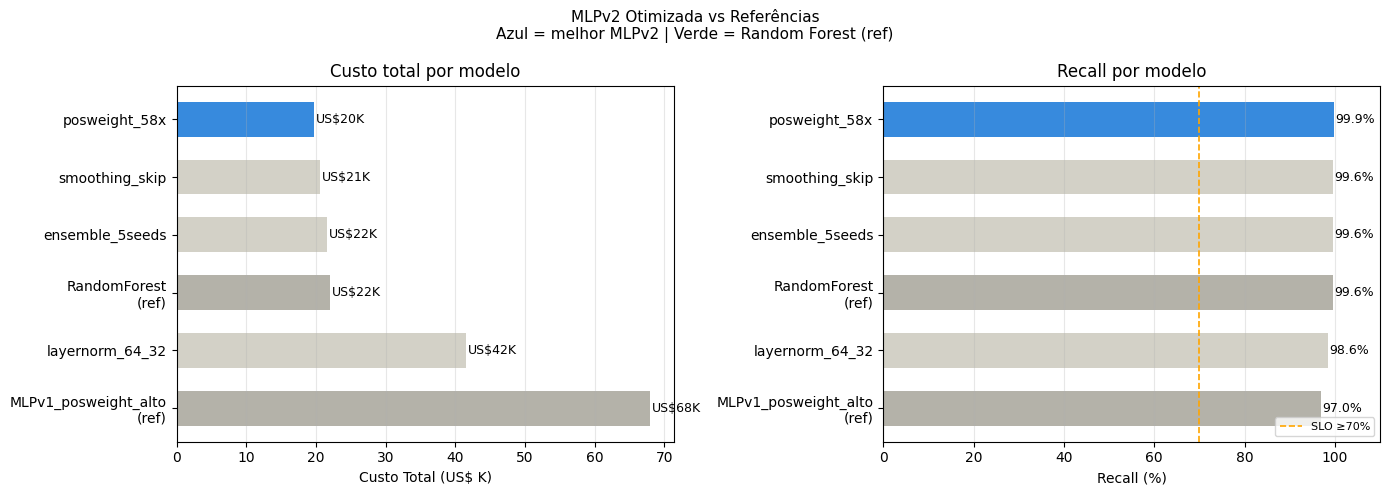

17:02:16 | INFO | Gráfico comparativo salvo | path=C:\Users\victo\Desktop\MLOPS\AULAS\tech_challenge_fase_1\tech_challenge\tech_challenge_1_fiap_mlops\reports\figures\comparativo_mlpv2_vs_ref.png
INFO:03_mlp_otimizacao:Gráfico comparativo salvo | path=C:\Users\victo\Desktop\MLOPS\AULAS\tech_challenge_fase_1\tech_challenge\tech_challenge_1_fiap_mlops\reports\figures\comparativo_mlpv2_vs_ref.png


In [14]:
FIGS_DIR = PROJECT_ROOT / "reports" / "figures"
FIGS_DIR.mkdir(parents=True, exist_ok=True)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
models_order = df_comp["model"].tolist()
costs = df_comp["cost_total_usd"].tolist()
recalls_raw = df_comp["recall"].tolist()
recalls = [r if pd.notna(r) else 0.0 for r in recalls_raw]


def _bar_color(name: str) -> str:
    if "RF" in name and "ref" in name:
        return "#5DCAA5"
    if "ref" in name:
        return "#B4B2A9"
    if best_mlpv2 and name == best_mlpv2["model"]:
        return "#378ADD"
    return "#D3D1C7"


colors = [_bar_color(n) for n in models_order]
short_names = [n.replace("MLPv2_", "").replace(" (ref)", "\n(ref)") for n in models_order]

ax = axes[0]
bars = ax.barh(short_names, [c / 1e3 for c in costs], color=colors, height=0.6)
ax.set(xlabel="Custo Total (US$ K)", title="Custo total por modelo")
ax.grid(axis="x", alpha=0.3)
ax.invert_yaxis()
for bar, val in zip(bars, costs):
    ax.text(
        bar.get_width() + 0.3, bar.get_y() + bar.get_height() / 2,
        f"US${val/1e3:.0f}K", ha="left", va="center", fontsize=9,
    )

ax = axes[1]
bars = ax.barh(short_names, [r * 100 for r in recalls], color=colors, height=0.6)
ax.set(xlabel="Recall (%)", title="Recall por modelo", xlim=(0, 110))
ax.axvline(70, color="orange", ls="--", lw=1.2, label="SLO ≥70%")
ax.grid(axis="x", alpha=0.3)
ax.invert_yaxis()
ax.legend(fontsize=8, loc="lower right")
for bar, val in zip(bars, recalls):
    ax.text(
        bar.get_width() + 0.3, bar.get_y() + bar.get_height() / 2,
        f"{val:.1%}", ha="left", va="center", fontsize=9,
    )

fig.suptitle(
    "MLPv2 Otimizada vs Referências\nAzul = melhor MLPv2 | Verde = Random Forest (ref)",
    fontsize=11,
)
fig.tight_layout()

chart_path = FIGS_DIR / "comparativo_mlpv2_vs_ref.png"
fig.savefig(chart_path, dpi=150, bbox_inches="tight")
plt.show()
logger.info("Gráfico comparativo salvo | path=%s", chart_path)

## 14. Artefatos finais no MLflow

In [15]:
MODELS_DIR = PROJECT_ROOT / "models"
MODELS_DIR.mkdir(parents=True, exist_ok=True)
FIGS_DIR = PROJECT_ROOT / "reports" / "figures"

mlflow.end_run()

comp_path = MODELS_DIR / "mlpv2_comparison.csv"
df_comp.to_csv(comp_path, index=False)

_model_map = {RUN_4A: model_4a, RUN_4B: model_4b, RUN_4C: model_4c}

if best_mlpv2 and best_mlpv2["model"] in _model_map:
    best_pt = MODELS_DIR / "best_mlpv2.pt"
    torch.save(_model_map[best_mlpv2["model"]].state_dict(), best_pt)
    logger.info("Melhor MLPv2 salvo | path=%s", best_pt)

with mlflow.start_run(run_name="mlpv2_final_artifacts"):
    mlflow.log_params(DATASET_META)
    mlflow.log_artifact(str(comp_path), "reports")
    mlflow.log_artifact(str(chart_path), "plots")
    if best_mlpv2 and best_mlpv2["model"] in _model_map:
        mlflow.log_artifact(str(best_pt), "final_model")
    if best_mlpv2:
        mlflow.log_metrics(
            {
                "winner_cost_usd": best_mlpv2["cost_total_usd"],
                "winner_recall": best_mlpv2["recall"],
                "winner_roc_auc": best_mlpv2["roc_auc"],
                "winner_fn": float(best_mlpv2["fn"]),
                "winner_cv_cost_mean": best_mlpv2.get("cv_cost_mean", float("nan")),
            }
        )
        mlflow.log_param("winner_model", best_mlpv2["model"])
    mlflow.set_tag("notebook", "03_mlp_otimizacao")

logger.info("Artefatos finais registrados | csv=%s", comp_path)
logger.info(
    "Notebook 03 concluído | melhor=%s | custo=US$%.0f | recall=%.1f%% | slo=%s",
    best_mlpv2["model"] if best_mlpv2 else "N/A",
    best_mlpv2["cost_total_usd"] if best_mlpv2 else 0,
    best_mlpv2["recall"] * 100 if best_mlpv2 else 0,
    "OK" if (best_mlpv2 and best_mlpv2["slo_ok"]) else "VIOLADO",
)

17:02:17 | INFO | Melhor MLPv2 salvo | path=C:\Users\victo\Desktop\MLOPS\AULAS\tech_challenge_fase_1\tech_challenge\tech_challenge_1_fiap_mlops\models\best_mlpv2.pt
INFO:03_mlp_otimizacao:Melhor MLPv2 salvo | path=C:\Users\victo\Desktop\MLOPS\AULAS\tech_challenge_fase_1\tech_challenge\tech_challenge_1_fiap_mlops\models\best_mlpv2.pt
17:02:17 | INFO | Artefatos finais registrados | csv=C:\Users\victo\Desktop\MLOPS\AULAS\tech_challenge_fase_1\tech_challenge\tech_challenge_1_fiap_mlops\models\mlpv2_comparison.csv
INFO:03_mlp_otimizacao:Artefatos finais registrados | csv=C:\Users\victo\Desktop\MLOPS\AULAS\tech_challenge_fase_1\tech_challenge\tech_challenge_1_fiap_mlops\models\mlpv2_comparison.csv
17:02:17 | INFO | Notebook 03 concluído | melhor=MLPv2_posweight_58x | custo=US$19703 | recall=99.9% | slo=OK
INFO:03_mlp_otimizacao:Notebook 03 concluído | melhor=MLPv2_posweight_58x | custo=US$19703 | recall=99.9% | slo=OK


---
## 15. Model Card

### Informações do modelo

| Campo | Valor |
|---|---|
| Nome | ChurnMLPv2 |
| Versão | 2.0 |
| Tarefa | Classificação binária — previsão de churn |
| Dataset | Telco Customer Churn (IBM) · n=7.043 · 30 features |
| Critério primário | Minimizar custo total: FN × US\$2.903 + FP × US\$50 |
| SLO | Recall ≥ 70% em dados de produção |
| Avaliação | StratifiedKFold 5-fold + hold-out 20% |

### Arquitetura

```
Input (30) → [Linear(30→64) → LayerNorm(64) → ReLU → Dropout(0.35)]
           → [Linear(64→32) → LayerNorm(32) → ReLU → Dropout(0.35)]
           → Linear(32→1)  →  logit  →  BCEWithLogitsLoss(pos_weight=58×)
```

- **Normalização:** `LayerNorm` — normaliza por amostra, estável com qualquer batch size
- **Otimizador:** `AdamW(lr=5e-4, weight_decay=1e-3)` — weight decay correto
- **Loss:** `BCEWithLogitsLoss(pos_weight=58.06)` — penaliza FN por 58× vs FP
- **Regularização:** Dropout + weight decay + early stopping (patience=25)
- **Threshold:** otimizado por varredura de custo, não fixo em 0.5

### Limitações conhecidas

1. **Distribuição de produção:** o threshold ótimo foi encontrado para a distribuição de treino (~26.5% churn). Deve ser recalibrado se a taxa de churn real divergir significativamente.

2. **Features estáticas:** o modelo usa snapshot do cliente, não sequências temporais. Mudanças de comportamento recentes não são capturadas.

3. **Generalização geográfica:** dataset IBM Telco é norte-americano. Uso em outros mercados exige retreinamento.

4. **Dados ausentes em inferência:** o preprocessor usa `SimpleImputer(median)`, mas features ausentes em features críticas podem degradar predições.

5. **Calibração de probabilidades:** as probabilidades de saída não são calibradas isotonicamente. Devem ser interpretadas como scores ordinais, não como probabilidades absolutas.

### Vieses documentados

1. **Viés de custo intencional:** o modelo é deliberadamente enviesado para minimizar FN (churners perdidos), gerando mais FP (alertas desnecessários). Razão FN/FP = 58× justifica essa escolha.

2. **Viés de contrato:** clientes `Month-to-month` têm taxa de churn muito mais alta (~43% vs ~11% nos anuais). O modelo pode estar usando contrato como proxy principal em vez de comportamento real.

3. **Viés de gênero:** a coluna `gender` está nas features. Análise de impacto diferencial por gênero não foi conduzida.

4. **Viés de antiguidade:** clientes novos (tenure < 6 meses) são sobre-representados nos churners. O modelo pode superestimar risco para clientes novos.

### Cenários de falha

- Clientes com `tenure_months = 0` (novos): probabilidades instáveis
- `total_charges` negativo ou zero: o log1p do preprocessor pode produzir valores anômalos
- Drift de produto: mudanças no portfólio de serviços podem tornar features obsoletas

### Plano de monitoramento

| Métrica | Frequência | Alerta |
|---|---|---|
| Recall realizado (churn confirmado 30 dias depois) | Mensal | < 70% |
| PSI do score de churn | Semanal | PSI > 0.20 |
| Taxa de churn real vs predita | Mensal | Delta > 5 pp |
| Custo realizado vs estimado | Trimestral | Divergência > 20% |
| Distribuição de features (KS test) | Semanal | p-value < 0.05 em ≥ 3 features |